## 6.4 양자 피셔 정보 (Quantum Fisher Information, QFI)

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 시뮬레이터 초기화
simulator = AerSimulator()

In [3]:
# 파라미터화된 위상 각도 정의
theta = Parameter('θ')

In [4]:
# 큐비트 2개로 양자 회로 생성
qc = QuantumCircuit(2)

In [5]:
# 초기 상태 준비
qc.h(0)  # 큐비트 0에 하다마드 게이트
qc.cx(0, 1)  # 큐비트 0과 1을 얽음

In [6]:
# 파라미터화된 위상 회전 적용
qc.rz(theta, 1)

In [7]:
# 측정 전 또 다른 하다마드 게이트
qc.h(0)

In [8]:
# 시뮬레이터용으로 회로 트랜스파일
try:
    compiled_circuit = transpile(qc, simulator)
except transpile.TranspileError:
    print("Transpilation failed! Check your circuit for compatibility issues.")
    exit()

In [9]:
# 유한 차분으로 QFI를 계산하는 함수
def finite_difference_qfi(circuit, theta_val, delta=1e-6):
    # 파라미터에 특정 값을 대입
    bound_qc_plus = circuit.assign_parameters({theta: theta_val + delta})
    bound_qc_minus = circuit.assign_parameters({theta: theta_val - delta})

    # 두 경우의 상태벡터 얻기
    state_plus = Statevector.from_instruction(bound_qc_plus)
    state_minus = Statevector.from_instruction(bound_qc_minus)

    # 유한 차분으로 QFI 계산
    qfi = 4 * (np.abs(state_plus.inner(state_minus) - state_minus.inner(state_plus)) / (2 * delta)) ** 2
    return qfi

In [10]:
# theta 범위에 대해 QFI 계산
theta_vals = np.linspace(0, 2 * np.pi, 100)
qfi_vals = [finite_difference_qfi(compiled_circuit, t) for t in theta_vals]

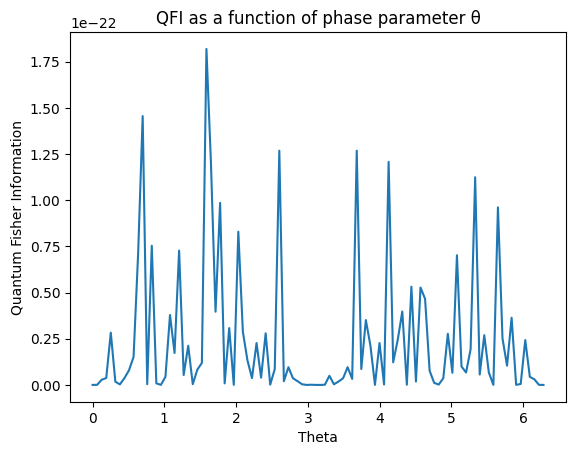

In [11]:
# 위상 파라미터 theta에 따른 QFI 그리기
plt.plot(theta_vals, qfi_vals)
plt.xlabel('Theta')
plt.ylabel('Quantum Fisher Information')
plt.title('QFI as a function of phase parameter θ')
plt.show()

In [12]:
# 최종 시뮬레이션을 위해 특정 파라미터 값 바인딩
final_circuit = compiled_circuit.assign_parameters({theta: 0})

In [13]:
# 최종 회로에 측정 추가
final_circuit.measure_all()

In [14]:
# 회로를 시뮬레이션·측정
result = simulator.run(final_circuit).result()

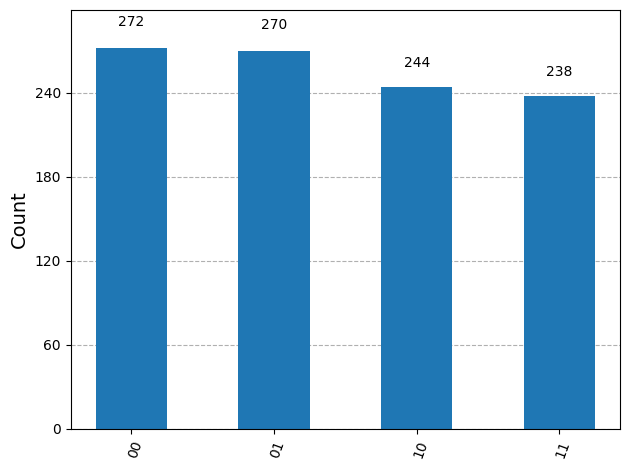

In [15]:
# 측정 결과 추출 및 그리기
counts = result.get_counts()
plot_histogram(counts)
plt.show()